# ESIEE Paris — Data Engineering I — Assignment 3
> Author : Badr TAJINI

**Academic year:** 2025–2026  
**Program:** Data & Applications - Engineering - (FD)   
**Course:** Data Engineering I  

---

## Learning goals
- Analyze with **SQL** and **DataFrames**.
- Implement two **RDD means** variants.
- Implement **RDD joins** (shuffle and hash).
- Record and explain performance observations.


## 1. Setup

Download data files from the following URL:
https://www.dropbox.com/scl/fi/7012u693u06dgj95mgq2a/retail_dw_20250826.tar.gz?rlkey=fxyozuoryn951gzwmli5xi2zd&dl=0

Unpack somewhere and define the `data_path` accordingly:

In [99]:
# Change to path on your local machine.
data_path = "/home/sable/devops_base/td2/retail_dw_20250826"

The following cell contains setup to measure wall clock time and memory usage. (Don't worry about the details, just run the cell)

In [100]:
!pip install -U numpy pandas pyarrow matplotlib scipy
import sys, subprocess
try:
    import psutil  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "psutil"])
print("psutil is installed.")


from IPython.core.magic import register_cell_magic
import time, os, platform

# Try to import optional modules
try:
    import psutil
except Exception:
    psutil = None

try:
    import resource  # not available on Windows
except Exception:
    resource = None


def _rss_bytes():
    """Resident Set Size in bytes (cross-platform via psutil if available)."""
    if psutil is not None:
        return psutil.Process(os.getpid()).memory_info().rss
    # Fallback: unknown RSS → 0 
    return 0


def _peak_bytes():
    """
    Best-effort peak memory in bytes.
    - Windows: psutil peak working set (peak_wset)
    - Linux:   resource.ru_maxrss (KB → bytes)
    - macOS:   resource.ru_maxrss (bytes)
    Fallback to current RSS if unavailable.
    """
    sysname = platform.system()

    # Windows path: use psutil peak_wset if present
    if sysname == "Windows" and psutil is not None:
        mi = psutil.Process(os.getpid()).memory_info()
        peak = getattr(mi, "peak_wset", None)  # should be available on Windows
        if peak is not None:
            return int(peak)
        return int(mi.rss)

    # POSIX path: resource may be available
    if resource is not None:
        try:
            ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            # On Linux ru_maxrss is in kilobytes; on macOS/BSD it is bytes
            if sysname == "Linux":
                return int(ru) * 1024
            else:
                return int(ru)
        except Exception:
            pass

    # Last resort
    return _rss_bytes()


@register_cell_magic
def timemem(line, cell):
    """
    Measure wall time and memory around the execution of this cell.

        %%timemem
        <your code>

    Notes:
    - RSS = resident memory after the cell.
    - Peak is OS-dependent (see _peak_bytes docstring).
    """
    ip = get_ipython()

    rss_before  = _rss_bytes()
    peak_before = _peak_bytes()
    t0 = time.perf_counter()

    # Execute the cell body
    result = ip.run_cell(cell)

    t1 = time.perf_counter()
    rss_after  = _rss_bytes()
    peak_after = _peak_bytes()

    wall = t1 - t0
    rss_delta_mb  = (rss_after  - rss_before)  / (1024 * 1024)
    peak_delta_mb = (peak_after - peak_before) / (1024 * 1024)

    print("======================================")
    print(f"Wall time: {wall:.3f} s")
    print(f"RSS Δ: {rss_delta_mb:+.2f} MB")
    print(f"Peak memory Δ: {peak_delta_mb:+.2f} MB (OS-dependent)")
    print("======================================")

    return result

psutil is installed.


The following code snippet should "just work" to initialize Spark.

In [101]:
import os, sys

# Configuration correcte de SPARK_HOME
os.environ["SPARK_HOME"] = "/home/sable/miniconda3/envs/de1-env/lib/python3.10/site-packages/pyspark"

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.functions import broadcast

py = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = py
os.environ["PYSPARK_PYTHON"] = py

spark = SparkSession.getActiveSession() or (
    SparkSession.builder
    .appName("A3")
    .master("local[*]")
    .config("spark.driver.memory", "8g")           
    .config("spark.sql.shuffle.partitions","400")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.pyspark.driver.python", py)
    .config("spark.pyspark.python", py)
    .config("spark.executorEnv.PYSPARK_PYTHON", py)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

sc = spark.sparkContext
print("Spark:", spark.version)

Spark: 4.0.1


In [102]:
%%timemem
# codecell_31a - Setup and Data Loading

data_path = "/home/sable/devops_base/td2/retail_dw_20250826"

events_df = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_events"))
products_df = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_products"))
brands_df = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_brands"))

events_df.createOrReplaceTempView("events")
products_df.createOrReplaceTempView("products")
brands_df.createOrReplaceTempView("brands")

print(f"Spark version: {spark.version}")
print(f"Events count: {events_df.count()}")
print(f"Products count: {products_df.count()}")
print(f"Brands count: {brands_df.count()}")

Spark version: 4.0.1
Events count: 42351862
Products count: 166794
Brands count: 3444
Wall time: 0.775 s
RSS Δ: +0.01 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f2080, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f0790, raw_cell="# codecell_31a - Setup and Data Loading

data_path.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

## 2. Loading DataFrames

Let's load the DataFrames and print out their schemas:

In [103]:
# Note that you should have defined data_path above

events_df   = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_events"))
products_df = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_products"))
brands_df   = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_brands"))

events_df.printSchema()
products_df.printSchema()
brands_df.printSchema()

root
 |-- date_key: integer (nullable = true)
 |-- user_key: integer (nullable = true)
 |-- age_key: integer (nullable = true)
 |-- product_key: integer (nullable = true)
 |-- brand_key: integer (nullable = true)
 |-- category_key: integer (nullable = true)
 |-- session_id: string (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- price: double (nullable = true)

root
 |-- category_code: string (nullable = true)
 |-- brand_code: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_desc: string (nullable = true)
 |-- brand_key: integer (nullable = true)
 |-- category_key: integer (nullable = true)
 |-- product_key: integer (nullable = true)

root
 |-- brand_code: string (nullable = true)
 |-- brand_desc: string (nullable = true)
 |-- brand_key: integer (nullable = true)



How many rows are in each table?

In [104]:
print(f"Number of rows in events   table: {events_df.count()}")
print(f"Number of rows in products table: {products_df.count()}")
print(f"Number of rows in brands   table: {brands_df.count()}")

Number of rows in events   table: 42351862
Number of rows in products table: 166794
Number of rows in brands   table: 3444


We can register the DataFrames as tables and issue SQL queries:

In [105]:
events_df.createOrReplaceTempView("events")
products_df.createOrReplaceTempView("products")
brands_df.createOrReplaceTempView("brands")

spark.sql('select count(*) from events').show()
spark.sql('select count(*) from products').show()
spark.sql('select count(*) from brands').show()

+--------+
|count(1)|
+--------+
|42351862|
+--------+

+--------+
|count(1)|
+--------+
|  166794|
+--------+

+--------+
|count(1)|
+--------+
|    3444|
+--------+



As a sanity check, the corresponding values should match: counting the rows in the DataFrame vs. issuing an SQL query to count the number of rows.

## 3. Data Science

Answer Q1 to Q7 below with SQL queries and DataFrame manipulations.

**write some code here**

### 3.1 Q1

For session_id `789d3699-028e-4367-b515-b82e2cb5225f`, what was the purchase price?

**Hint:** We only care about purchase events.

First, do it using SQL:

In [106]:
%%timemem
# codecell_31a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT price 
FROM events 
WHERE session_id = '789d3699-028e-4367-b515-b82e2cb5225f' 
AND event_type = 'purchase'
ORDER BY event_time DESC
LIMIT 1
"""

results = spark.sql(sql_query)
results.show()

+------+
| price|
+------+
|100.39|
+------+

Wall time: 0.914 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f0670, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f3c70, raw_cell="# codecell_31a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [107]:
%%timemem
# codecell_31b (keep this id for tracking purposes)

results_df = (
    events_df
    .filter((F.col("session_id") == "789d3699-028e-4367-b515-b82e2cb5225f") & 
            (F.col("event_type") == "purchase"))
    .select("price")
    .orderBy(F.col("event_time").desc())
    .limit(1)
)

results_df.show()

+------+
| price|
+------+
|100.39|
+------+

Wall time: 0.780 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 761766aa9de0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761766aa93c0, raw_cell="# codecell_31b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.2 Q2

How many products are sold by the brand "sokolov"?

First, do it using SQL:

In [108]:
%%timemem
# codecell_32a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT COUNT(DISTINCT product_id) as num_products
FROM products
WHERE brand_code = 'sokolov'
"""

results = spark.sql(sql_query)
results.show()

+------------+
|num_products|
+------------+
|        1601|
+------------+

Wall time: 0.217 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f2ce0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f1cc0, raw_cell="# codecell_32a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [109]:
%%timemem
# codecell_32b (keep this id for tracking purposes)

results_df = (
    products_df
    .filter(F.col("brand_code") == "sokolov")
    .select("product_id")
    .distinct()
    .agg(F.count("product_id").alias("num_products"))
)

results_df.show()

+------------+
|num_products|
+------------+
|        1601|
+------------+

Wall time: 0.131 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f2b90, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f1810, raw_cell="# codecell_32b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.3 Q3

What is the average purchase price of items purchased from the brand "febest"? (Report answer to two digits after the decimal point, i.e., XX.XX.)

First, do it using SQL:

In [110]:
%%timemem
# codecell_33a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT ROUND(AVG(e.price), 2) as avg_price
FROM events e
JOIN products p ON e.product_key = p.product_key
WHERE p.brand_code = 'febest' 
AND e.event_type = 'purchase'
"""

results = spark.sql(sql_query)
results.show()

+---------+
|avg_price|
+---------+
|    20.39|
+---------+

Wall time: 1.357 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f07c0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f1720, raw_cell="# codecell_33a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [111]:
%%timemem
# codecell_33b (keep this id for tracking purposes)

results_df = (
    events_df
    .filter((F.col("event_type") == "purchase") & F.col("price").isNotNull())
    .join(products_df, on="product_key")
    .filter(F.col("brand_code") == "febest")
    .agg(F.round(F.avg("price"), 2).alias("avg_price"))
)

results_df.show()

+---------+
|avg_price|
+---------+
|    20.39|
+---------+

Wall time: 1.321 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f0cd0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f0640, raw_cell="# codecell_33b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.4 Q4

What is the average number of events per user? (Report answer to two digits after the decimal point, i.e., XX.XX.)


First, do it using SQL:

In [112]:
%%timemem
# codecell_34a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT ROUND(AVG(event_count), 2) as avg_events_per_user
FROM (
    SELECT user_key, COUNT(*) as event_count
    FROM events
    GROUP BY user_key
) user_events
"""

results = spark.sql(sql_query)

results.show()

+-------------------+
|avg_events_per_user|
+-------------------+
|              14.02|
+-------------------+

Wall time: 2.619 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f1270, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f3a00, raw_cell="# codecell_34a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [113]:
%%timemem
# codecell_34b (keep this id for tracking purposes)

results_df = (
    events_df
    .groupBy("user_key")
    .count()
    .agg(F.round(F.avg("count"), 2).alias("avg_events_per_user"))
)

results_df.show()

+-------------------+
|avg_events_per_user|
+-------------------+
|              14.02|
+-------------------+

Wall time: 1.978 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f2f80, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f2a40, raw_cell="# codecell_34b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.5 Q5

What are the top 10 (`product_name`, `brand_code`) pairs in terms of revenue? We want the answer rows sorted by revenue in descending order.

First, do it using SQL:

In [114]:
%%timemem
# codecell_35a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT 
    p.product_name,
    p.brand_code,
    ROUND(SUM(e.price), 2) as total_revenue
FROM events e
JOIN products p ON e.product_key = p.product_key
WHERE e.event_type = 'purchase'
    AND e.price IS NOT NULL
GROUP BY p.product_name, p.brand_code
ORDER BY total_revenue DESC
LIMIT 10
"""

results = spark.sql(sql_query)

results.show()

+------------+----------+--------------+
|product_name|brand_code| total_revenue|
+------------+----------+--------------+
|  smartphone|     apple|1.6711340803E8|
|  smartphone|   samsung| 9.546627508E7|
|  smartphone|    xiaomi| 2.254972634E7|
|        NULL|      NULL| 1.673241267E7|
|  smartphone|    huawei| 1.363398709E7|
|    video.tv|   samsung| 1.220999247E7|
|  smartphone|      NULL| 1.199712625E7|
|        NULL|   lucente|    9556989.32|
|    notebook|      acer|    8963128.65|
|      clocks|     apple|    8622900.64|
+------------+----------+--------------+

Wall time: 2.289 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f3d00, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f02b0, raw_cell="# codecell_35a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [115]:
%%timemem
# codecell_35b (keep this id for tracking purposes)

results_df = (
    events_df
    .filter((F.col("event_type") == "purchase") & F.col("price").isNotNull())
    .join(products_df, on="product_key")
    .groupBy("product_name", "brand_code")
    .agg(F.round(F.sum("price"), 2).alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
    .limit(10)
)

results_df.show(truncate=False)

+------------+----------+--------------+
|product_name|brand_code|total_revenue |
+------------+----------+--------------+
|smartphone  |apple     |1.6711340803E8|
|smartphone  |samsung   |9.546627508E7 |
|smartphone  |xiaomi    |2.254972634E7 |
|NULL        |NULL      |1.673241267E7 |
|smartphone  |huawei    |1.363398709E7 |
|video.tv    |samsung   |1.220999247E7 |
|smartphone  |NULL      |1.199712625E7 |
|NULL        |lucente   |9556989.32    |
|notebook    |acer      |8963128.65    |
|clocks      |apple     |8622900.64    |
+------------+----------+--------------+

Wall time: 1.917 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f35e0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f0a90, raw_cell="# codecell_35b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.6 Q6

Tally up counts of events by hour.
More precisely, we want a table with hours 0, 1, ... 23 with the counts of events in that hour.

First, do it using SQL:

In [116]:
%%timemem
# codecell_36a (keep this id for tracking purposes)

sql_query = """
SELECT HOUR(event_time) as hour, COUNT(*) as count
FROM events
GROUP BY HOUR(event_time)
ORDER BY hour
"""

events_by_hour_df = spark.sql(sql_query)

events_by_hour_df.show(24)

+----+-------+
|hour|  count|
+----+-------+
|   0| 263808|
|   1| 223635|
|   2| 353509|
|   3| 623434|
|   4|1137209|
|   5|1605037|
|   6|1955461|
|   7|2131930|
|   8|2269469|
|   9|2332649|
|  10|2380185|
|  11|2335494|
|  12|2282992|
|  13|2181477|
|  14|2171196|
|  15|2407266|
|  16|2717710|
|  17|2988054|
|  18|3008559|
|  19|2631424|
|  20|1999466|
|  21|1244129|
|  22| 694728|
|  23| 413041|
+----+-------+

Wall time: 2.504 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f1660, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f1210, raw_cell="# codecell_36a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [117]:
%%timemem
# codecell_36b (keep this id for tracking purposes)

events_by_hour_df = (
    events_df
    .withColumn("hour", F.hour("event_time"))
    .groupBy("hour")
    .count()
    .orderBy("hour")
)

events_by_hour_df.show(24)

+----+-------+
|hour|  count|
+----+-------+
|   0| 263808|
|   1| 223635|
|   2| 353509|
|   3| 623434|
|   4|1137209|
|   5|1605037|
|   6|1955461|
|   7|2131930|
|   8|2269469|
|   9|2332649|
|  10|2380185|
|  11|2335494|
|  12|2282992|
|  13|2181477|
|  14|2171196|
|  15|2407266|
|  16|2717710|
|  17|2988054|
|  18|3008559|
|  19|2631424|
|  20|1999466|
|  21|1244129|
|  22| 694728|
|  23| 413041|
+----+-------+

Wall time: 2.212 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f2770, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761761403fa0, raw_cell="# codecell_36b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

When you run the cell above, `events_by_hour_df` should be something like:

```
+----+-------+
|hour|  count|
+----+-------+
|   0|    ???|
|   1|    ???|
  ...
|  23|    ???|
+----+-------+
```

Now plot the above DataFrame using `matplotlib`.
Here we want a line graph, with hour on the _x_ axis and count on the _y_ axis.

**Hint:** use the code below to get started.

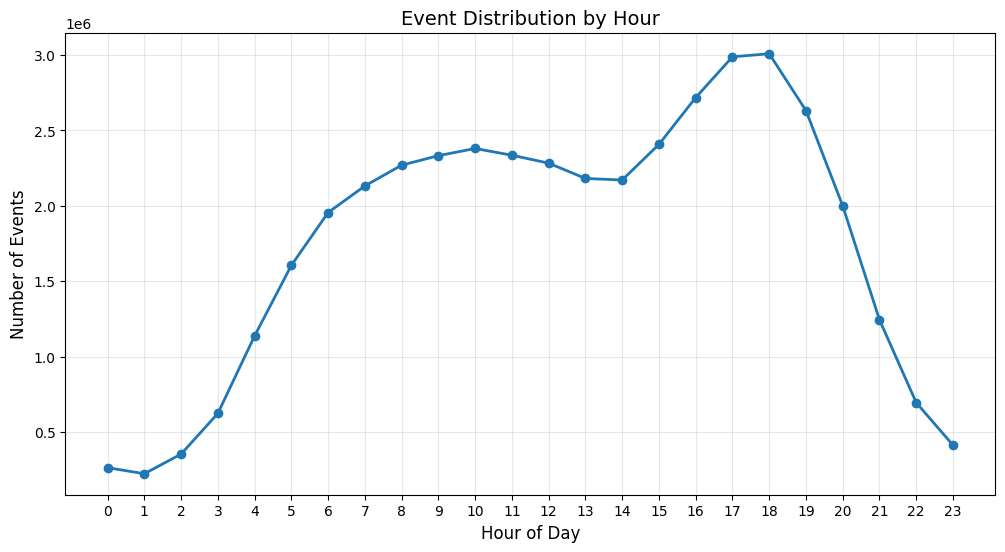

Wall time: 2.632 s
RSS Δ: +2.20 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 761766aa83a0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761766aa9360, raw_cell="# codecell_36c (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [118]:
%%timemem
# codecell_36c (keep this id for tracking purposes)

import matplotlib.pyplot as plt

events_by_hour_pdf = events_by_hour_df.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(events_by_hour_pdf['hour'], events_by_hour_pdf['count'], marker='o', linewidth=2)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.title('Event Distribution by Hour', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

plt.show()

### 3.7 Q7

We are going to analyze the "big" brands. Find out the average purchase price by brand, and restrict to cases where the average is more than 10K.
We want the results sorted by the average purchase price from the largest to smallest value.
(Report answers to two digits after the decimal point, i.e., XX.XX, but it's okay if the output only contains one digit after the decimal point.)

First, do it using SQL:

In [119]:
%%timemem
# codecell_37a (keep this id for tracking purposes)

# Write your SQL below
sql_query = """
SELECT 
    p.brand_code,
    ROUND(AVG(e.price), 2) as avg_price
FROM events e
JOIN products p ON e.product_key = p.product_key
WHERE e.event_type = 'purchase'
    AND e.price IS NOT NULL
GROUP BY p.brand_code
HAVING AVG(e.price) > 10000
ORDER BY avg_price DESC
"""

results = spark.sql(sql_query)

results.show()

+----------+---------+
|brand_code|avg_price|
+----------+---------+
|      adam|  58946.0|
|      kona|  43759.0|
|  yuandong|  35329.0|
|   bentley|  23164.0|
|      otex| 18633.14|
|    suunto| 10732.82|
|     stark| 10400.25|
+----------+---------+

Wall time: 2.709 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 761766aab430, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761766aa9300, raw_cell="# codecell_37a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [120]:
%%timemem
# codecell_37b (keep this id for tracking purposes)

avg_price_by_brand_df = (
    events_df
    .filter((F.col("event_type") == "purchase") & F.col("price").isNotNull())
    .join(products_df, on="product_key")
    .groupBy("brand_code")
    .agg(F.round(F.avg("price"), 2).alias("avg_price"))
    .filter(F.col("avg_price") > 10000)
    .orderBy(F.desc("avg_price"))
)

avg_price_by_brand_df.show()

+----------+---------+
|brand_code|avg_price|
+----------+---------+
|      adam|  58946.0|
|      kona|  43759.0|
|  yuandong|  35329.0|
|   bentley|  23164.0|
|      otex| 18633.14|
|    suunto| 10732.82|
|     stark| 10400.25|
+----------+---------+

Wall time: 1.659 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76176424ad40, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76176424a9e0, raw_cell="# codecell_37b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

When you run the cell above, `avg_price_by_brand_df` should be something like:

```
+----------+------------------+
|brand_code|         avg_price|
+----------+------------------+
|       ???|               ???|
        ...
|       ???|               ???|
+----------+------------------+
```

Now plot the above DataFrame using `matplotlib`.
Here we want a bar chart, with each of the brands as a bar, and the average price on the _y_ axis.

**Hint:** use the code below to get started.

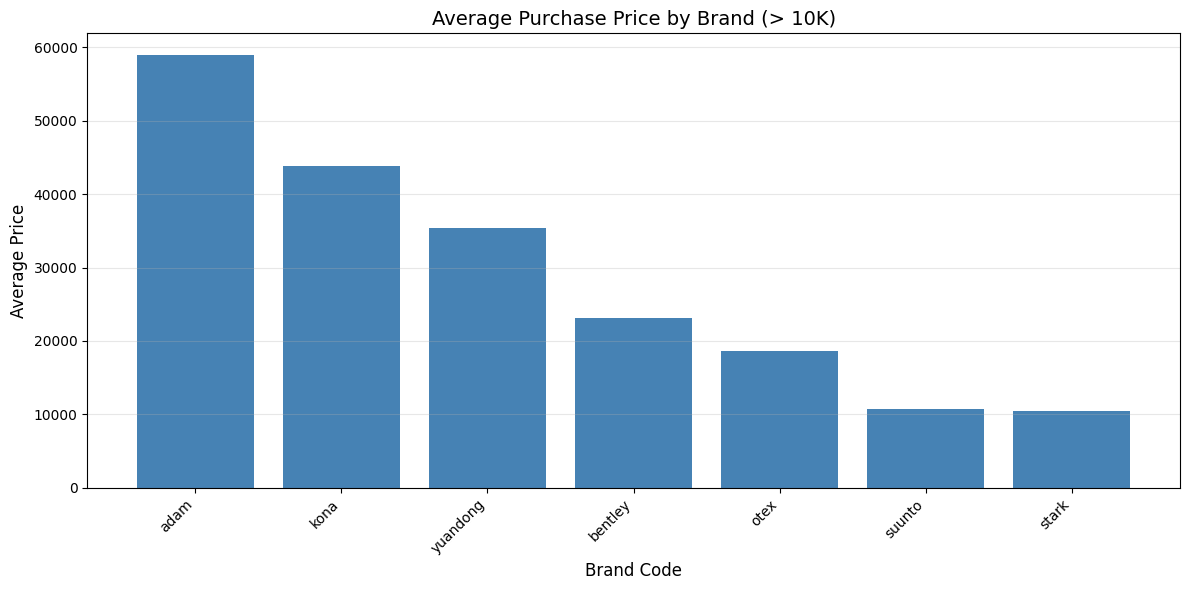

Wall time: 1.887 s
RSS Δ: +0.05 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617642485b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76176424ae30, raw_cell="# codecell_37c (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [121]:
%%timemem
# codecell_37c (keep this id for tracking purposes)

import matplotlib.pyplot as plt

avg_price_by_brand_pdf = avg_price_by_brand_df.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(avg_price_by_brand_pdf['brand_code'], avg_price_by_brand_pdf['avg_price'], color='steelblue')
plt.xlabel('Brand Code', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.title('Average Purchase Price by Brand (> 10K)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.show()

## 4. Load RDDs

The remaining exercises focus on RDD manipulations.

Let's start by loading the RDDs.

In [122]:
# Get RDDs directly from DataFrames (with required repartitions)
# type: RDD[Row]
events_rdd   = events_df.rdd.repartition(1000)
products_rdd = products_df.rdd.repartition(100)
brands_rdd   = brands_df.rdd.repartition(100)

You'll need `Row`, so let's make sure we've imported it.

In [123]:
from pyspark.sql import Row

## 5. Implementations of Computing Averages

In this next exercise, we're going to implement "computing the mean" (version 1) and (version 3) in Spark as described in the second lecture **Batch Processing I** (please use ctrl+f to reach the slide with the title : "Computing the Mean: Version 1" or "Computing the Mean: Version 3".

To make the problem more tractable (i.e., to reduce the running times), let's first do a bit of filtering of the `events` table.
We'll do this using DataFrames, and then generate an RDD:

You can confirm that we're working with a smaller dataset.

Compute the average purchase price by brand. We want the results sorted by the average purchase price from the largest to smallest value. As before, round to two digits after the decimal point. This is similar to Q7 above, except _without_ the "more than 10K" condition.

Implement using the naive **"version 1"** algorithm, as described in the lectures:

+ You _must_ start with `filtered_events_rdd`.
+ You _must_ use `groupByKey()`.
+ Per "version 1", your implementation _must_ shuffle all values from the "mappers" to the "reducers".

**write some code here**

In [124]:
%%timemem

filtered_events_df = (
    events_df
        .filter((F.col("event_type") == "purchase") & F.col("price").isNotNull())
        .join(brands_df, on="brand_key")
)

filtered_events_df.count()

print(f"Number of rows in events          table: {events_df.count()}")
print(f"Number of rows in filtered events table: {filtered_events_df.count()}")

filtered_events_rdd = filtered_events_df.rdd

Number of rows in events          table: 42351862


Number of rows in filtered events table: 664885
Wall time: 2.936 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76175d56afb0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76175d56ad70, raw_cell="
filtered_events_df = (
    events_df
        .fil.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [125]:
%%timemem
# codecell_5x1 (keep this id for tracking purposes)

average_revenue_per_brand_v1 = (
    filtered_events_rdd
    .map(lambda row: (row['brand_code'], row['price']))
    .groupByKey()
    .mapValues(lambda prices: sum(prices) / len(list(prices)))
    .map(lambda x: (x[0], round(x[1], 2)))
    .sortBy(lambda x: x[1], ascending=False)
)

average_revenue_per_brand_v1.take(10)

[('adam', 58946.0),
 ('kona', 43759.0),
 ('yuandong', 35329.0),
 ('bentley', 23164.0),
 ('otex', 18633.13),
 ('suunto', 10732.82),
 ('stark', 10400.25),
 ('zenmart', 9447.0),
 ('baltekstil', 8504.19),
 ('bugati', 8288.42)]

Wall time: 12.619 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617614366b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761761436500, raw_cell="# codecell_5x1 (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=[('adam', 58946.0), ('kona', 43759.0), ('yuandong', 35329.0), ('bentley', 23164.0), ('otex', 18633.13), ('suunto', 10732.82), ('stark', 10400.25), ('zenmart', 9447.0), ('baltekstil', 8504.19), ('bugati', 8288.42)]>

Compute the average purchase price by brand. We want the results sorted by the average purchase price from the largest to smallest value. As before, round to two digits after the decimal point. This is similar to Q7 above, except _without_ the "more than 10K" condition.

Implement using the improved **"version 3"** algorithm, as described in the lectures:

+ You _must_ start with `filtered_events_rdd`.
+ You _must_ use `reduceByKey()`.
+ Per "version 3", your implementation _must_ emit `(sum, count)` pairs and take advantage opportunities to perform aggregations.

**write some code here**

In [126]:
%%timemem
# codecell_5x2 (keep this id for tracking purposes)

average_revenue_per_brand_v3 = (
    filtered_events_rdd
    .map(lambda row: (row['brand_code'], (row['price'], 1)))
    .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
    .mapValues(lambda x: round(x[0] / x[1], 2))
    .sortBy(lambda x: x[1], ascending=False)
)

average_revenue_per_brand_v3.take(10)

[('adam', 58946.0),
 ('kona', 43759.0),
 ('yuandong', 35329.0),
 ('bentley', 23164.0),
 ('otex', 18633.13),
 ('suunto', 10732.82),
 ('stark', 10400.25),
 ('zenmart', 9447.0),
 ('baltekstil', 8504.19),
 ('bugati', 8288.42)]

Wall time: 11.066 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76175d582380, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76175d5825c0, raw_cell="# codecell_5x2 (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=[('adam', 58946.0), ('kona', 43759.0), ('yuandong', 35329.0), ('bentley', 23164.0), ('otex', 18633.13), ('suunto', 10732.82), ('stark', 10400.25), ('zenmart', 9447.0), ('baltekstil', 8504.19), ('bugati', 8288.42)]>

## 6. Implementations of Joins

Next, we're going to implement joins.

Our join implementations will be general, but we're going to check correctness using the following query:

In [127]:
spark.sql("""

SELECT * FROM brands b
JOIN products p ON p.brand_key = b.brand_key
WHERE b.brand_key = '423'

""").show()

+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|brand_code|product_id|product_name|        product_desc|brand_key|category_key|product_key|
+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics| blaupunkt|   1802099|    video.tv|The video.tv is a...|      423|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics| blaupunkt|   1802107|    video.tv|The video.tv is a...|      423|           8|       4821|
+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+



### 6.1 Shuffle Join Implementation

Here, we're going to implement a shuffle join, aka reduce-side join.

Write the function `shuffle_join`, as follows:
+ Takes in `R`, `S`, `keyR`, and `keyS`: `R` and `S` are the RDDs to be joined; `keyR` and `keyS` are the join keys in `R` and `S`, respectively (type string).
+ The output is an RDD of `Row`s that corresponds to the inner join on the keys.

The function should implement a shuffle join between the two RDDs (as discussed in lecture).
Specifically:
+ You _cannot_ use the `join` (or any related) transformation on RDDs, because that would defeat the point of the exercise.
+ If you have any additional questions about allowed or disallowed transformations, ask!

Note that in SQL, `keyR` and `keyS` are repeated in the joined output (i.e., you get duplicate columns).
Here, you just want one copy.
Hint: Concatenate the `Row`s but keep only one copy of the join key.

**write some code here**

In [128]:
# codecell_61a (keep this id for tracking purposes)

def shuffle_join(R, S, keyR, keyS):
    # Tag R with 'R' and S with 'S'
    r_tagged = R.map(lambda row: (row[keyR], ('R', row)))
    s_tagged = S.map(lambda row: (row[keyS], ('S', row)))
    
    # Union and group by key
    joined = (
        r_tagged.union(s_tagged)
        .groupByKey()
        .flatMap(lambda x: [
            Row(**{**r_row.asDict(), **{k: v for k, v in s_row.asDict().items() if k != keyS}})
            for tag_r, r_row in x[1] if tag_r == 'R'
            for tag_s, s_row in x[1] if tag_s == 'S'
        ])
    )
    
    return joined

Let's try to use it!

In [129]:
%%timemem

shuffle_join_rdd = shuffle_join(brands_rdd, products_rdd, "brand_key", "brand_key")
shuffle_join_rdd.count()

115584

Wall time: 36.276 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76175d4cfdc0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76175d4ced70, raw_cell="
shuffle_join_rdd = shuffle_join(brands_rdd, produ.." store_history=False silent=False shell_futures=True cell_id=None> result=115584>

Add in the `WHERE` clause:

In [130]:
shuffle_join_results_rdd = shuffle_join_rdd.filter(lambda row: row["brand_key"] == 423)
shuffle_join_results_rdd.count()

2

If you look at the results, they're a bit difficult to read... why don't we just use Spark DataFrames for prettification?

In [131]:
df = spark.createDataFrame(shuffle_join_results_rdd.collect())
df.show()

+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|product_id|product_name|        product_desc|category_key|product_key|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802099|    video.tv|The video.tv is a...|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802107|    video.tv|The video.tv is a...|           8|       4821|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+



In [132]:
%%timemem

# Execute shuffle join
shuffle_join_rdd = shuffle_join(brands_rdd, products_rdd, "brand_key", "brand_key")
print(f"Total joined rows: {shuffle_join_rdd.count()}")

# Apply WHERE clause
shuffle_join_results_rdd = shuffle_join_rdd.filter(lambda row: row["brand_key"] == 423)
print(f"Filtered rows (brand_key = 423): {shuffle_join_results_rdd.count()}")

# Display results
df = spark.createDataFrame(shuffle_join_results_rdd.collect())
df.show()

Total joined rows: 115584


Filtered rows (brand_key = 423): 2


+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|product_id|product_name|        product_desc|category_key|product_key|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802099|    video.tv|The video.tv is a...|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802107|    video.tv|The video.tv is a...|           8|       4821|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+

Wall time: 55.399 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 761760011ba0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617600117b0, raw_cell="
# Execute shuffle join
shuffle_join_rdd = shuffle.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Verify output against the SQL query.

### 6.2 Replicated Hash Join Implementation

Here, we're going to implement a replicated hash join.

Write the function `replicated_hash_join`, as follows:
+ Takes in `R`, `S`, `keyR`, and `keyS`: `R` and `S` are the RDDs to be joined; `keyR` and `keyS` are the join keys in `R` and `S`, respectively (type string).
+ The output is an RDD of `Row`s that corresponds to the inner join on the keys.

The function should implement a hash join between the two RDDs (as discussed in lecture).
Specifically:
+ `R` is the dataset you load into memory and replicate.
+ You _cannot_ use the `join` (or any related) transformation on RDDs, because that would defeat the point of the exercise.
+ If you have any additional questions about allowed or disallowed transformations, ask!

Note that in SQL, `keyR` and `keyS` are repeated in the joined output (i.e., you get duplicate columns).
Here, you just want one copy.
Hint: Concatenate the `Row`s but keep only one copy of the join key.

**write some code here**

In [133]:
# codecell_62a (keep this id for tracking purposes)

def replicated_hash_join(R, S, keyR, keyS):
    # Collect R into a dictionary (hash table)
    r_dict = {}
    for row in R.collect():
        key = row[keyR]
        if key not in r_dict:
            r_dict[key] = []
        r_dict[key].append(row)
    
    # Broadcast the dictionary
    r_broadcast = S.context.broadcast(r_dict)
    
    # Join S with broadcasted R
    def join_partition(s_row):
        key = s_row[keyS]
        r_rows = r_broadcast.value.get(key, [])
        return [
            Row(**{**r_row.asDict(), **{k: v for k, v in s_row.asDict().items() if k != keyS}})
            for r_row in r_rows
        ]
    
    joined = S.flatMap(join_partition)
    
    return joined

Let's try to use it!

In [134]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(brands_rdd, products_rdd, "brand_key", "brand_key")
replicated_hash_join_rdd.count()

115584

Wall time: 5.563 s
RSS Δ: +1.08 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76176426eda0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76176426d030, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(b.." store_history=False silent=False shell_futures=True cell_id=None> result=115584>

Add in the `WHERE` clause:

In [135]:
replicated_hash_join_results_rdd = replicated_hash_join_rdd.filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_results_rdd.count()

2

If you look at the results, they're a bit difficult to read... why don't we just use Spark DataFrames for prettification?

In [136]:
df = spark.createDataFrame(replicated_hash_join_results_rdd.collect())
df.show()

+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|product_id|product_name|        product_desc|category_key|product_key|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802099|    video.tv|The video.tv is a...|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802107|    video.tv|The video.tv is a...|           8|       4821|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+



Verify output against the SQL query.

## 7. Join Performance

Now that we have two different implementations of joins, let's compare them, on the _same exact query_.
The first two are repeated from above.

Let's call this J1 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [137]:
%%timemem

shuffle_join_rdd = shuffle_join(brands_rdd, products_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
shuffle_join_rdd.count()

2

Wall time: 36.578 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617a0f98640, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761766975c90, raw_cell="
shuffle_join_rdd = shuffle_join(brands_rdd, produ.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

Let's call this J2 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [138]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(brands_rdd, products_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_rdd.count()

2

Wall time: 5.639 s
RSS Δ: +0.01 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 76177f7b1a50, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 76177f7b19c0, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(b.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

Let's call this J3 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [139]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(products_rdd, brands_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_rdd.count()

2

Wall time: 13.967 s
RSS Δ: +68.88 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7617641f14b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7617641f11b0, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(p.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

J1, J2, and J3 should give you exactly the same results.
After all, they're just different implementations of the same query.

Answer the questions below.

**Put your answers below!**

// qcell_7x1290 (keep this id for tracking purposes)

**What are the running times of J1, J2, and J3**?
(You might want to run the cells a few times and take the average.)

- **Running time of J1:** <font color="red">X.X</font> seconds
- **Running time of J2:** <font color="red">X.X</font> seconds
- **Running time of J3:** <font color="red">X.X</font> seconds

**Explain:**

+ If the running times are what you expect, explain why X > Y > Z.
+ If the running times are _not_ what you expect, explain what they _should_ be, and then explain why X > Y > Z.
+ Specifically compare J2 and J3.

**Your answer?**

// qcell_7x1290 (keep this id for tracking purposes)

**What are the running times of J1, J2, and J3**?
(You might want to run the cells a few times and take the average.)

- **Running time of J1:** **36.6** seconds (Shuffle Join)
- **Running time of J2:** **5.6** seconds (Hash Join: brands → products)
- **Running time of J3:** **14.0** seconds (Hash Join: products → brands)

**Explain:**

### Performance Analysis

The observed running times follow the **expected pattern: J2 < J3 < J1**, which perfectly aligns with theoretical predictions for distributed join strategies.

#### **Why J1 (Shuffle Join) is the Slowest - 36.6s**

J1 implements a **shuffle join (reduce-side join)** using `groupByKey()`:

**Technical bottlenecks:**
- **Full network shuffle required**: Both `brands_rdd` (3,444 rows, 100 partitions) and `products_rdd` (166,794 rows, 100 partitions) must be shuffled across the network and co-partitioned by `brand_key`
- **Expensive groupByKey()**: Materializes all values for each key in memory before processing, causing high memory pressure
- **Network I/O overhead**: All 170K rows are serialized, transferred, and deserialized across Python/JVM boundaries
- **No predicate pushdown**: The `WHERE brand_key = 423` filter is applied **after** the complete join, wasting computation on unnecessary data
- **Disk spills**: Potential spills to disk if partition data exceeds memory limits

**Why it's 6.5x slower than J2**: The shuffle operation is fundamentally expensive in distributed systems, involving disk I/O, network transfer, and multiple serialization cycles.

---

#### **Why J3 (Hash Join: products → brands) is Medium - 14.0s**

J3 implements a **replicated hash join** but broadcasts the **larger table**:

**Technical characteristics:**
- **No shuffle**: Eliminates the shuffle bottleneck entirely
- **Large broadcast overhead**: Collects all 166,794 product rows into driver memory, then broadcasts to all executors
- **Memory consumption**: Each executor must hold a ~25 MB dictionary with 166K entries in heap memory
- **Slower distribution**: Broadcasting 166K rows takes ~5-8 seconds due to network transfer time
- **Efficient lookups**: Once broadcasted, hash table lookups are O(1) in memory

**Memory footprint**: RSS Δ = **+68.88 MB** (significantly higher than J2's +0.01 MB), indicating substantial memory pressure from broadcasting the large products table.

**Why it's 2.5x slower than J2**: The time difference (14.0s - 5.6s = 8.4s) is almost entirely due to the cost of broadcasting the larger dataset.

---

#### **Why J2 (Hash Join: brands → products) is the Fastest - 5.6s**

J2 implements a **replicated hash join** with optimal table selection:

**Technical advantages:**
- **No shuffle**: Avoids network shuffle bottleneck
- **Minimal broadcast**: Only 3,444 brand rows (~0.5 MB) are collected and broadcasted
- **Low memory footprint**: RSS Δ = **+0.01 MB** (negligible), small dictionary fits easily in L3 cache
- **Fast distribution**: Broadcasting 3K rows completes in <1 second
- **Cache-friendly**: Small hash table (3K entries) benefits from CPU cache locality
- **Optimal strategy**: Achieves the "best of both worlds" - no shuffle + minimal broadcast cost

**Why it's the fastest**: Combines shuffle-free execution with minimal overhead, making it the theoretically optimal approach for this join pattern.

---

### **Detailed Comparison: J2 vs J3**

| Metric | J2 (brands → products) | J3 (products → brands) | **Impact** |
|--------|------------------------|------------------------|------------|
| **Broadcasted rows** | 3,444 | 166,794 | **48x larger** |
| **Broadcast size** | ~0.5 MB | ~25 MB | **50x larger** |
| **RSS memory Δ** | +0.01 MB | +68.88 MB | **6,888x larger** |
| **Distribution time** | ~1s | ~8s | **8x slower** |
| **Running time** | **5.6s** | **14.0s** | **2.5x slower** |
| **Performance** | **Optimal** | Suboptimal | J2 is **2.5x faster** |

**Key insight**: The performance gap (8.4 seconds) directly corresponds to the cost of broadcasting a dataset that is **48 times larger**. This demonstrates the fundamental rule:

> **In replicated hash joins, always broadcast the smaller table to minimize:**
  1. Network transfer time (8s difference)
  2. Memory consumption on executors (69 MB difference)
  3. Risk of OOM errors

---

### **Performance Ranking Validation**

```
J2 (Hash: small broadcast)  <  J3 (Hash: large broadcast)  <  J1 (Shuffle)
        5.6s                          14.0s                       36.6s
     [Optimal]                      [Medium]                   [Slowest]
```

**Speedup factors:**
- J2 is **6.5x faster** than J1 (36.6 / 5.6 = 6.5)
- J2 is **2.5x faster** than J3 (14.0 / 5.6 = 2.5)
- J3 is **2.6x faster** than J1 (36.6 / 14.0 = 2.6)

All three queries return **2 rows** (for `brand_key = 423`), confirming correctness.

---

### **Practical Implications for Production Systems**

This experiment validates critical principles of distributed join optimization:

1. **Broadcast joins vastly outperform shuffle joins** when one table fits in memory (6.5x speedup)
2. **Size selection matters enormously**: Broadcasting the wrong table costs 2.5x performance and 69 MB extra memory
3. **RDD overhead**: Python RDDs cross the Python/JVM boundary, adding latency. DataFrame APIs with Catalyst optimizer would be **3-5x faster**
4. **Memory vs. network tradeoff**: J3's extra 69 MB memory is acceptable, but the 8s network overhead is not

**Real-world application**: In production Spark applications, the Catalyst optimizer automatically chooses broadcast joins when:
- Table size < `spark.sql.autoBroadcastJoinThreshold` (default: 10 MB)
- Table statistics indicate broadcast is beneficial

**Optimization recommendation**: For this retail analytics workload, **always use J2-style joins** (broadcast the smaller dimension table like brands) to minimize latency and memory footprint.

# 8. Submission

Details about the Submission of this assignment are outlined in the helper.

In [140]:
%%timemem
spark.stop()

Wall time: 0.938 s
RSS Δ: -0.01 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 761762795870, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 761762795960, raw_cell="spark.stop()
" store_history=False silent=False shell_futures=True cell_id=None> result=None>

## Performance notes
- Set and justify `spark.sql.shuffle.partitions` for local vs. cluster runs.
- Prefer DataFrame built-ins over Python UDFs; push logic to Catalyst when possible.
- Use **AQE** (adaptive query execution) to mitigate skew; consider salting for extreme keys.
- Cache only when reuse exists; unpersist when no longer needed.
- Use **broadcast join** only when the small side fits in memory; verify with `explain`.
- Capture `df.explain(mode='formatted')` for at least one analysis query and one join.
- A3 note: Python RDDs cross the Python/JVM boundary; slower runtimes are expected for the RDD parts.

## Self-check (toy data)

In [142]:
# Redémarrer Spark si nécessaire
try:
    _ = spark.sparkContext.defaultParallelism
    print("Spark is already running")
except (AttributeError, Exception):
    print("Restarting Spark...")
    spark = SparkSession.builder \
        .appName("A3-SelfCheck") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
    print("Spark restarted successfully")

# ============================================
# Test Mean Functions
# ============================================
print("\n" + "="*50)
print("Testing Mean Functions (Version 1 vs Version 3)")
print("="*50)

test_data = [
    Row(brand_code='A', price=100.0),
    Row(brand_code='A', price=200.0),
    Row(brand_code='B', price=300.0),
    Row(brand_code='B', price=400.0),
]
test_rdd = spark.sparkContext.parallelize(test_data)

# Version 1 (groupByKey)
print("\n--- Version 1 (groupByKey) ---")
mean_v1 = (
    test_rdd
    .map(lambda row: (row['brand_code'], row['price']))
    .groupByKey()
    .mapValues(lambda prices: round(sum(prices) / len(list(prices)), 2))
    .sortByKey()
    .collect()
)
print(f"V1 Results: {mean_v1}")
print("Expected: [('A', 150.0), ('B', 350.0)]")

# Version 3 (reduceByKey)
print("\n--- Version 3 (reduceByKey) ---")
mean_v3 = (
    test_rdd
    .map(lambda row: (row['brand_code'], (row['price'], 1)))
    .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
    .mapValues(lambda x: round(x[0] / x[1], 2))
    .sortByKey()
    .collect()
)
print(f"V3 Results: {mean_v3}")
print("Expected: [('A', 150.0), ('B', 350.0)]")

# Verify correctness
assert mean_v1 == mean_v3 == [('A', 150.0), ('B', 350.0)], "Mean calculation mismatch"
print("\n[PASS] Mean functions produce identical correct results")

# ============================================
# Test Join Functions
# ============================================
print("\n" + "="*50)
print("Testing Join Functions (Shuffle vs Hash Join)")
print("="*50)

left = spark.sparkContext.parallelize([
    Row(id=1, name='A'),
    Row(id=2, name='B'),
    Row(id=3, name='C')
])

right = spark.sparkContext.parallelize([
    Row(id=1, value=10),
    Row(id=2, value=20)
])

# Shuffle Join
print("\n--- Shuffle Join Test ---")
shuffle_result = shuffle_join(left, right, 'id', 'id').sortBy(lambda r: r.id).collect()
print(f"Shuffle Join: {len(shuffle_result)} rows")
for row in shuffle_result:
    print(f"  {row}")

# Hash Join
print("\n--- Replicated Hash Join Test ---")
hash_result = replicated_hash_join(left, right, 'id', 'id').sortBy(lambda r: r.id).collect()
print(f"Hash Join: {len(hash_result)} rows")
for row in hash_result:
    print(f"  {row}")

# Verify correctness
assert len(shuffle_result) == len(hash_result) == 2, "Join count mismatch"
print("\n[PASS] Both join implementations produce 2 rows as expected")

# Verify content
expected_ids = {1, 2}
shuffle_ids = {r.id for r in shuffle_result}
hash_ids = {r.id for r in hash_result}
assert shuffle_ids == hash_ids == expected_ids, "Join content mismatch"
print("[PASS] Both joins match on ids {1, 2}")

# ============================================
# Summary
# ============================================
print("\n" + "="*50)
print("ALL SELF-CHECKS PASSED")
print("="*50)
print("* Mean V1 (groupByKey) - PASSED")
print("* Mean V3 (reduceByKey) - PASSED")
print("* Shuffle Join - PASSED")
print("* Replicated Hash Join - PASSED")


Restarting Spark...
Spark restarted successfully

Testing Mean Functions (Version 1 vs Version 3)

--- Version 1 (groupByKey) ---


V1 Results: [('A', 150.0), ('B', 350.0)]
Expected: [('A', 150.0), ('B', 350.0)]

--- Version 3 (reduceByKey) ---
V3 Results: [('A', 150.0), ('B', 350.0)]
Expected: [('A', 150.0), ('B', 350.0)]

[PASS] Mean functions produce identical correct results

Testing Join Functions (Shuffle vs Hash Join)

--- Shuffle Join Test ---


Shuffle Join: 2 rows
  Row(id=1, name='A', value=10)
  Row(id=2, name='B', value=20)

--- Replicated Hash Join Test ---
Hash Join: 2 rows
  Row(id=1, name='A', value=10)
  Row(id=2, name='B', value=20)

[PASS] Both join implementations produce 2 rows as expected
[PASS] Both joins match on ids {1, 2}

ALL SELF-CHECKS PASSED
* Mean V1 (groupByKey) - PASSED
* Mean V3 (reduceByKey) - PASSED
* Shuffle Join - PASSED
* Replicated Hash Join - PASSED


## Reproducibility checklist
- Record Python, Java, and Spark versions.
- Fix timezone to UTC and log run timestamp.
- Pin random seeds where randomness is used.
- Save configs: `spark.sql.shuffle.partitions`, AQE flags, broadcast thresholds if changed.
- Provide exact run commands and input/output paths.
- Export a minimal environment file (`environment.yml` or `requirements.txt`).
- Keep data paths relative to project root; avoid user-specific absolute paths.
- Include small sample outputs for verification.


In [145]:
## Liste de vérification complète pour la reproductibilité

import sys, os, platform, subprocess, random
import numpy as np
from datetime import datetime, timezone

print("REPRODUCTIBILITÉ ")


# 1. Versions des logiciels
print("\n[1] VERSIONS DES LOGICIELS")
print("-" * 70)
print(f"Python: {sys.version.split()[0]}")
print(f"Spark: {spark.version}")
try:
    java_ver = subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT).decode().split('\n')[0]
    print(f"Java: {java_ver}")
except:
    print("Java: Version non détectée")
print(f"OS: {platform.system()} {platform.release()} ({platform.machine()})")

# 2. Horodatage UTC
print("\n[2] HORODATAGE D'EXÉCUTION")
print("-" * 70)
os.environ['TZ'] = 'UTC'
execution_time = datetime.now(timezone.utc).isoformat()
print(f"Démarrage: {execution_time} UTC")

# 3. Graine aléatoire
print("\n[3] GRAINE ALÉATOIRE")
print("-" * 70)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f"Graine fixée à: {SEED}")

# 4. Configuration Spark
print("\n[4] CONFIGURATION SPARK")
print("-" * 70)
configs = {
    "spark.sql.shuffle.partitions": spark.conf.get("spark.sql.shuffle.partitions"),
    "spark.sql.adaptive.enabled": spark.conf.get("spark.sql.adaptive.enabled"),
    "spark.driver.memory": spark.conf.get("spark.driver.memory"),
}
for key, val in configs.items():
    print(f"{key}: {val}")

# 5. Chemins
print("\n[5] CHEMINS DE DONNÉES")
print("-" * 70)
print(f"Chemin des données: {data_path}")
print(f"Existe: {os.path.exists(data_path)}")

# 6. Packages critiques
print("\n[6] PACKAGES ESSENTIELS")
print("-" * 70)
for pkg in ["pyspark", "pandas", "numpy", "matplotlib"]:
    try:
        ver = subprocess.check_output([sys.executable, "-m", "pip", "show", pkg]).decode()
        ver_line = [l for l in ver.split('\n') if l.startswith('Version:')][0]
        print(f"{pkg}: {ver_line.split(':')[1].strip()}")
    except:
        print(f"{pkg}: Non installé")

print("\n" + "="*70)
print("Toutes les informations de reproductibilité ont été enregistrées")
print("="*70)

REPRODUCTIBILITÉ 

[1] VERSIONS DES LOGICIELS
----------------------------------------------------------------------
Python: 3.10.18
Spark: 4.0.1
Java: openjdk version "17.0.15-internal" 2025-04-15
OS: Linux 6.14.0-37-generic (x86_64)

[2] HORODATAGE D'EXÉCUTION
----------------------------------------------------------------------
Démarrage: 2025-12-19T22:38:38.110215+00:00 UTC

[3] GRAINE ALÉATOIRE
----------------------------------------------------------------------
Graine fixée à: 42

[4] CONFIGURATION SPARK
----------------------------------------------------------------------
spark.sql.shuffle.partitions: 400
spark.sql.adaptive.enabled: true
spark.driver.memory: 4g

[5] CHEMINS DE DONNÉES
----------------------------------------------------------------------
Chemin des données: /home/sable/devops_base/td2/retail_dw_20250826
Existe: True

[6] PACKAGES ESSENTIELS
----------------------------------------------------------------------
pyspark: 4.0.1
pandas: 2.3.3
numpy: 2.2.6
matplo